# Baseline Models - AMES Mutagenicity 

**Goal**: Establish baseline performance of the AMES dataset before moving to GNNs and GDL.
**Dataset**: AMES - 7255 molecules, bindary classification (mutagenic vs. non-mutagenic)

### Basline hierarchy
| Level | Model | Representation | Question it answers |
|-------|-------|----------------|---------------------|
| 0 | Majority-class / Random | None | Is this task learnable? |
| 1a | Randeom Forest | Morgan Fingerprints (ECFP4) | How far do engineered features go? |
| 1b | XGBoost | Morgan Fingerprints (ECFP4) | Best classical ML? |
| 1c | Random Forest | RDKit 2D Descriptors | Do physicochemical properties help? |
| 2 | ChemBERTa (fine-tuned) |  SMILES tokens (PLM) | Do learned representations beat fingerprints? |
| 3 | GCN / GIN / GAT | Molecular graph | *(next notebook)* |
| 4 | SchNet / DimeNet | 3D Conformer | *(stretch goal)* 

## 1.Setup & Data Loading

In [3]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    f1_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier

from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, rdMolDescriptors

from tdc.single_pred import Tox

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Paths
DATA_PATH = "../data"
PLOTS_PATH = "../plots"

print("Setup complete. Libraries imported and paths defined.")

Setup complete. Libraries imported and paths defined.


In [4]:
import urllib.request

# Load the dataset using TDC with defual scaffold split
data_ames = Tox(name="Ames", path=DATA_PATH)
split = data_ames.get_split()

train_df = split["train"]
val_df = split["valid"]
test_df = split["test"]

print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
print(
    f'\nLabel distribution in Train set:\n{train_df["Y"].value_counts(normalize=True).round(3)}'
)

Found local copy...
Loading...
Done!


Train: 5,094 | Val: 728 | Test: 1,456

Label distribution in Train set:
Y
1    0.542
0    0.458
Name: proportion, dtype: float64


## 2. Feature Engineering

### 2a. Morgan Fingerprints (ECFP4)
Circular fingerprints of radius 2, 1024 bits- the gold standard molecular representation for classical ML.


In [5]:
from rdkit.Chem import rdFingerprintGenerator

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)

def smiles_to_morgan_fp(smiles):
    """Convert a SMILES string to a Morgan fingerprint (ECFP4) bit vector."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return morgan_gen.GetFingerprintAsNumPy(mol)

def featurize_morgan(df):
    """Featurize a TDC dataframe with Morgan fingerprints."""
    fps = []
    labels = []
    valid_idx = []
    for idx, row in df.iterrows():
        fp = smiles_to_morgan_fp(row['Drug'])
        if fp is not None:
            fps.append(fp)
            labels.append(row['Y'])
            valid_idx.append(idx)
    return np.array(fps), np.array(labels)

X_train_fp, y_train = featurize_morgan(train_df)
X_val_fp, y_val = featurize_morgan(val_df)
X_test_fp, y_test = featurize_morgan(test_df)

print(f'Morgan FP Shapes - Train: {X_train_fp.shape}, Val: {X_val_fp.shape}, Test: {X_test_fp.shape}')

Morgan FP Shapes - Train: (5094, 1024), Val: (728, 1024), Test: (1456, 1024)


### 2b. RDKit 2D Phsicochemical Descriptors

A set of interpretable molecular properties: molecular wieght, LogP, TPSA, H-bond donors/acceptors, etc.

In [6]:
def smiles_to_descriptors(smiles):
    """Convert a SMILES string to a vector of molecular descriptors."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return [
        Descriptors.MolWt(mol),  # Molecular weight
        Descriptors.MolLogP(mol),  # LogP (lipophilicity)
        Descriptors.TPSA(mol),  # Topological polar surface area
        Descriptors.NumHDonors(mol),  # Number of hydrogen bond donors
        Descriptors.NumHAcceptors(mol),  # Number of hydrogen bond acceptors
        Descriptors.NumRotatableBonds(mol),  # Number of rotatable bonds
        Descriptors.RingCount(mol),  # Number of rings
        Descriptors.NumAromaticRings(mol),  # Number of aromatic rings
        Descriptors.FractionCSP3(mol),  # Fraction of sp3 carbons
        rdMolDescriptors.CalcNumHeavyAtoms(mol),  # Number of heavy atoms
    ]


DESC_NAMES = [
    "MolWt",
    "LogP",
    "TPSA",
    "HBD",
    "HBA",
    "RotBonds",
    "Rings",
    "AromaticRings",
    "FracCSP3",
    "HeavyAtoms",
]


def featurize_descriptors(df):
    """Featurize a TDC dataframe with RDKit 2D descriptors."""
    descs = []
    labels = []

    for _, row in df.iterrows():
        desc = smiles_to_descriptors(row["Drug"])
        if desc is not None:
            descs.append(desc)
            labels.append(row["Y"])

    return np.array(descs), np.array(labels)


X_train_desc, _ = featurize_descriptors(train_df)
X_val_desc, _ = featurize_descriptors(val_df)
X_test_desc, _ = featurize_descriptors(test_df)

print(
    f"Descriptor Shapes - Train: {X_train_desc.shape}, Val: {X_val_desc.shape}, Test: {X_test_desc.shape}"
)
print(f"\nDescriptor Names: {DESC_NAMES}")

Descriptor Shapes - Train: (5094, 10), Val: (728, 10), Test: (1456, 10)

Descriptor Names: ['MolWt', 'LogP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'Rings', 'AromaticRings', 'FracCSP3', 'HeavyAtoms']


## 3. Level 0 - Naive Baselines

The floor: what do we get with zero learning?

In [7]:
# --- Results collector ---
results = []


def evaluate_and_store(name, y_true, y_pred, y_prob=None):
    """Compute metrics and append to results list"""

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob) if y_prob is not None else np.nan

    results.append({"Model": name, "Accuracy": acc, "ROC AUC": auc, "F1 Score": f1})

    print(f"{name:30s}  Accuracy={acc:.4f} | F1 Score={f1:.4f} | ROC AUC= {auc:.4f}")
    return acc, f1, auc


# --- Majority Class Baseline ---
dummy_majority = DummyClassifier(strategy="most_frequent", random_state=SEED)
dummy_majority.fit(X_train_fp, y_train)
y_pred_dummy_majority = dummy_majority.predict(X_test_fp)
evaluate_and_store("Dummy (Majority)", y_test, y_pred_dummy_majority)

# --- Stratified Random Baseline ---
dummy_strat = DummyClassifier(strategy="stratified", random_state=SEED)
dummy_strat.fit(X_train_fp, y_train)
y_pred_dummy_strat = dummy_strat.predict(X_test_fp)
y_prob_dummy_strat = dummy_strat.predict_proba(X_test_fp)[:, 1]  # Prob for positive class
evaluate_and_store("Dummy (Stratified)", y_test, y_pred_dummy_strat, y_prob_dummy_strat)

Dummy (Majority)                Accuracy=0.5481 | F1 Score=0.7081 | ROC AUC= nan
Dummy (Stratified)              Accuracy=0.5199 | F1 Score=0.5573 | ROC AUC= 0.5166


(0.5199175824175825, 0.5573147561747942, 0.5165706820242095)

## 4. Level 1 - Classical ML + Molecular Fingerprints

### 4a. Random Forest + Morgan Fingerprints (ECFP4)

In [8]:
rf_morgan = RandomForestClassifier(
    n_estimators=500, max_depth=None, min_samples_leaf=2, n_jobs=-1, random_state=SEED
)
rf_morgan.fit(X_train_fp, y_train)

y_pred_rf = rf_morgan.predict(X_test_fp)
y_prob_rf = rf_morgan.predict_proba(X_test_fp)[:, 1]  # Prob for positive class

evaluate_and_store("RF + Morgan FP", y_test, y_pred_rf, y_prob_rf)
print(
    classification_report(
        y_test, y_pred_rf, target_names=["Non-Mutagenic", "Mutagenic"]
    ),
)

RF + Morgan FP                  Accuracy=0.8249 | F1 Score=0.8389 | ROC AUC= 0.9002
               precision    recall  f1-score   support

Non-Mutagenic       0.80      0.82      0.81       658
    Mutagenic       0.85      0.83      0.84       798

     accuracy                           0.82      1456
    macro avg       0.82      0.82      0.82      1456
 weighted avg       0.83      0.82      0.83      1456



### 4b. XGBoost + Morgan Fingerprints (ECFP4)

In [9]:
xgb_morgan = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=SEED,
    n_jobs=-1,
)
xgb_morgan.fit(X_train_fp, y_train, eval_set=[(X_val_fp, y_val)], verbose=False)

y_pred_xgb = xgb_morgan.predict(X_test_fp)
y_prob_xgb = xgb_morgan.predict_proba(X_test_fp)[:, 1]

evaluate_and_store("XGB + Morgan FP", y_test, y_pred_xgb, y_prob_xgb)
print(
    classification_report(
        y_test, y_pred_xgb, target_names=["Non-Mutagenic", "Mutagenic"]
    ),
)

XGB + Morgan FP                 Accuracy=0.8255 | F1 Score=0.8416 | ROC AUC= 0.8994
               precision    recall  f1-score   support

Non-Mutagenic       0.81      0.80      0.81       658
    Mutagenic       0.84      0.85      0.84       798

     accuracy                           0.83      1456
    macro avg       0.82      0.82      0.82      1456
 weighted avg       0.83      0.83      0.83      1456



### 4c. Random Forest + RDKit 2D Descriptors

In [10]:
rf_desc = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=SEED,
)
rf_desc.fit(X_train_desc, y_train)

y_pred_rf_desc = rf_desc.predict(X_test_desc)
y_prob_rf_desc = rf_desc.predict_proba(X_test_desc)[:, 1]

evaluate_and_store("RF + RDKit Descriptors", y_test, y_pred_rf_desc, y_prob_rf_desc)
print(
    classification_report(
        y_test, y_pred_rf_desc, target_names=["Non-Mutagenic", "Mutagenic"]
    ),
)

RF + RDKit Descriptors          Accuracy=0.7864 | F1 Score=0.8060 | ROC AUC= 0.8668
               precision    recall  f1-score   support

Non-Mutagenic       0.77      0.76      0.76       658
    Mutagenic       0.80      0.81      0.81       798

     accuracy                           0.79      1456
    macro avg       0.78      0.78      0.78      1456
 weighted avg       0.79      0.79      0.79      1456



### 4d. Feature Importance (Morgan Fingerprints)

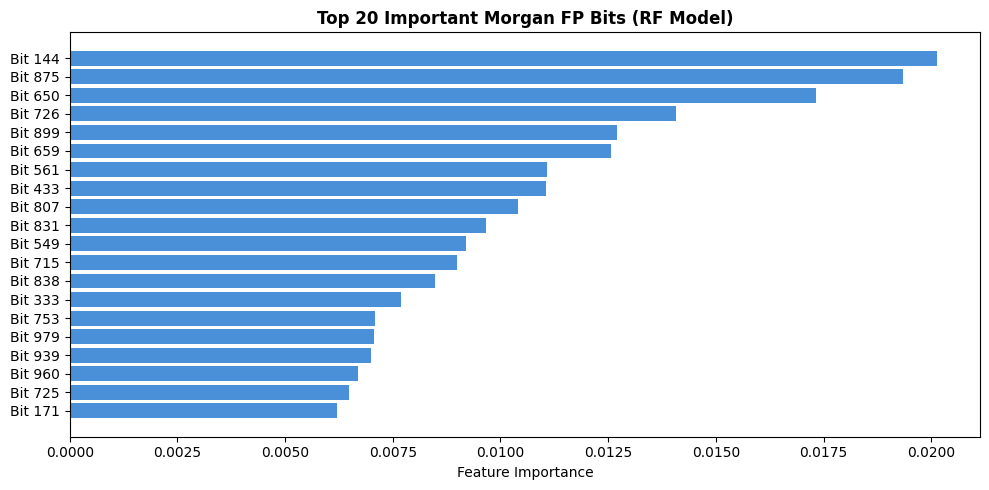

In [11]:
# Top 20 most important fingerprint bits from Random Forest model
importances = rf_morgan.feature_importances_
top_20_indices = np.argsort(importances)[-20:][::-1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(range(20), importances[top_20_indices][::-1], color="#4A90D9")
ax.set_yticks(range(20))
ax.set_yticklabels([f"Bit {i}" for i in top_20_indices])
ax.set_xlabel("Feature Importance")
ax.set_title("Top 20 Important Morgan FP Bits (RF Model)",fontweight="bold")
plt.tight_layout()
plt.savefig(f"{PLOTS_PATH}/baseline_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

### 4e. Feature Importance (RDKit 2D Descriptors)

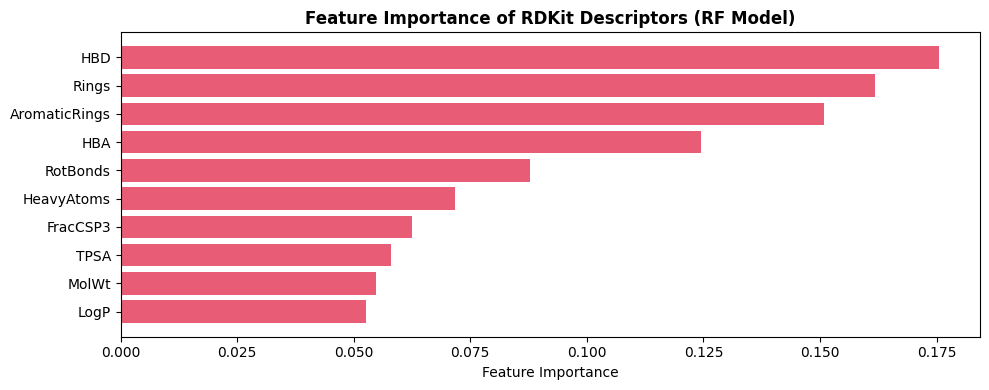

In [12]:
# Descriptor importance from Random Forest model - More interpretable than fingerprint bits
desc_importances = rf_desc.feature_importances_
sorted_indices = np.argsort(desc_importances)[::-1]

fig, ax = plt.subplots(figsize=(10,4))
ax.barh(range(len(DESC_NAMES)), desc_importances[sorted_indices][::-1], color="#E85D75")
ax.set_yticks(range(len(DESC_NAMES)))
ax.set_yticklabels([DESC_NAMES[i] for i in sorted_indices])
ax.set_xlabel("Feature Importance")
ax.set_title("Feature Importance of RDKit Descriptors (RF Model)",fontweight="bold")
plt.tight_layout()
plt.savefig(f"{PLOTS_PATH}/baseline_descriptor_importance.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Level 2 -- Pre-trained Language Model (ChemBERTa)

ChemBERTa is a RoBERTa model pre-trained on ~77M SMILES strings.
It learns molecular representations directly from SMILES **text** - no fingerprints, no graph.
This is the critical baseline: *does a PLM already capture enough chemistry from syntax alone?*

In [13]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader as TorchDataLoader

# If PyTorch was installed as CPU-only, torch.version.cuda is None.
use_cuda = (torch.version.cuda is not None) and torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [14]:
import os
import shutil
from transformers import AutoTokenizer, AutoModelForMaskedLM
# from transformers import AutoTokenizer, AutoModel
from huggingface_hub import hf_hub_download, constants


from dotenv import load_dotenv

# Load the .env file
load_dotenv()

MODEL_NAME = "DeepChem/ChemBERTa-77M-MLM"

HF_TOKEN = os.getenv("HF_TOKEN")
if HF_TOKEN is None:
    raise ValueError("HF_TOKEN environment variable not set. Please set it to your Hugging Face API token.")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, token=HF_TOKEN)
mlm_model = AutoModelForMaskedLM.from_pretrained(MODEL_NAME, token=HF_TOKEN)

# The above model is the full masked language model, which includes a head for predicting masked tokens. For our purposes, we only need the backbone (the part that produces hidden states), so we can load that directly. The AutoModel class will load the backbone without the MLM head.
backbone = mlm_model.base_model

print(f"Model {MODEL_NAME} loaded successfully.")
print(f'Hidden size: {backbone.config.hidden_size}')
print(f'Parameters: {sum(p.numel() for p in backbone.parameters()):,}')

Loading weights: 100%|██████████| 60/60 [00:00<00:00, 9739.47it/s]

Model DeepChem/ChemBERTa-77M-MLM loaded successfully.
Hidden size: 384
Parameters: 3,279,600


In [15]:
class SMILESDataset(Dataset):
    """PyTorch Dataset for tokenizing SMILES strings using a Hugging Face tokenizer."""
    def __init__(self, df, tokenizer, max_length=128):
        self.smiles = df['Drug'].tolist()
        self.labels = df['Y'].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.smiles[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_length,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),  # Remove batch dimension
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label':          torch.tensor(self.labels[idx], dtype=torch.float)  # Assuming binary classification
        }
        
BATCH_SIZE = 32

train_datasett = SMILESDataset(train_df, tokenizer)
val_datasett = SMILESDataset(val_df, tokenizer)
test_datasett = SMILESDataset(test_df, tokenizer)

train_loader_plm = TorchDataLoader(train_datasett, batch_size=BATCH_SIZE, shuffle=True)
val_loader_plm = TorchDataLoader(val_datasett, batch_size=BATCH_SIZE)
test_loader_plm = TorchDataLoader(test_datasett, batch_size=BATCH_SIZE)

print(f"Train batches: {len(train_loader_plm)} | Val batches: {len(val_loader_plm)} | Test batches: {len(test_loader_plm)}")

Train batches: 160 | Val batches: 23 | Test batches: 46


In [16]:
class ChemBERTaClassifier(nn.Module):
    """ChemBERTa backbone + classification head.
    
    Strategy: freeze backbone, train only the head.
    Can optionally unfreeze last N layers for fine-tuning.
    """
    def __init__(self, backbone, hidden_size, dropout=0.2, freeze_backbone=True):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128,1)
        )
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False
                
    def forward(self, input_ids, attention_mask):
        outputs = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        # Use [CLS] token representation (first token)
        cls_embedding = outputs.last_hidden_state[:, 0, :]
        logits = self.head(cls_embedding)
        return logits.squeeze(-1)
        
model = ChemBERTaClassifier(
    backbone=backbone,
    hidden_size=backbone.config.hidden_size,
    freeze_backbone=True
).to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable: {trainable:,} / {total:,} parameters ({100*trainable/total:1f}%)')
            

Trainable: 49,409 / 3,329,009 parameters (1.484195%)


In [17]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(labels)  # Accumulate total loss weighted by batch size
    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, criterion,device):
    model.eval()
    total_loss = 0
    all_labels, all_probs = [], []
    
    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)
        total_loss += loss.item() * len(labels)  # Accumulate total loss weighted by batch size
        
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels)
    
    avg_loss = total_loss / len(loader.dataset)
    all_probs= np.array(all_probs)
    all_labels = np.array(all_labels)
    preds = (all_probs >= 0.5).astype(int)
    acc = accuracy_score(all_labels, preds)
    auc = roc_auc_score(all_labels, all_probs)
    f1 = f1_score(all_labels, preds)

    return avg_loss, acc, auc, f1, all_probs, all_labels

In [18]:
# ---- Training loop ----
NUM_EPOCHS = 15
LR = 1e-3 # higher LR since backbone is frozen - only training the head, which has far fewer parameters than the full model. If we were fine-tuning the entire model, we would typically use a lower learning rate (e.g., 1e-5 to 5e-5) to avoid catastrophic forgetting and ensure stable training.

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
criterion = nn.BCEWithLogitsLoss()

best_val_auc = 0
history = {'train_loss': [], 'val_loss': [], 'val_auc': []}

for epoch in range(1, NUM_EPOCHS+1):
    train_loss = train_one_epoch(model, train_loader_plm, optimizer, criterion, device)
    val_loss, val_acc, val_auc, val_f1, _, _ = evaluate(model, val_loader_plm, criterion, device)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_auc)
    

    
    marker = ' * Best' if val_auc > best_val_auc else ''
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}  # Save a copy of the best model's state_dict
        
    print(f'Epoch {epoch:02d}/{NUM_EPOCHS} '
          f'Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} '
          f'Val AUC: {val_auc:.4f} | Val F1: {val_f1:.4f}{marker}')
    
# Restore best model state
model.load_state_dict(best_state)
print(f'\nRestored best model ( Val AUC: {best_val_auc:.4f} )')

Epoch 01/15 Train Loss: 0.6555 | Val Loss: 0.6286 Val AUC: 0.7183 | Val F1: 0.6190 * Best
Epoch 02/15 Train Loss: 0.6283 | Val Loss: 0.5972 Val AUC: 0.7449 | Val F1: 0.7240 * Best
Epoch 03/15 Train Loss: 0.6134 | Val Loss: 0.5853 Val AUC: 0.7545 | Val F1: 0.7125 * Best
Epoch 04/15 Train Loss: 0.6095 | Val Loss: 0.5902 Val AUC: 0.7634 | Val F1: 0.6766 * Best
Epoch 05/15 Train Loss: 0.5984 | Val Loss: 0.5835 Val AUC: 0.7552 | Val F1: 0.7266
Epoch 06/15 Train Loss: 0.5988 | Val Loss: 0.5744 Val AUC: 0.7680 | Val F1: 0.7396 * Best
Epoch 07/15 Train Loss: 0.5895 | Val Loss: 0.5664 Val AUC: 0.7779 | Val F1: 0.7506 * Best
Epoch 08/15 Train Loss: 0.5852 | Val Loss: 0.5646 Val AUC: 0.7780 | Val F1: 0.7338 * Best
Epoch 09/15 Train Loss: 0.5775 | Val Loss: 0.5736 Val AUC: 0.7729 | Val F1: 0.7103
Epoch 10/15 Train Loss: 0.5772 | Val Loss: 0.5675 Val AUC: 0.7795 | Val F1: 0.7045 * Best
Epoch 11/15 Train Loss: 0.5733 | Val Loss: 0.5624 Val AUC: 0.7838 | Val F1: 0.7266 * Best
Epoch 12/15 Train Loss: 

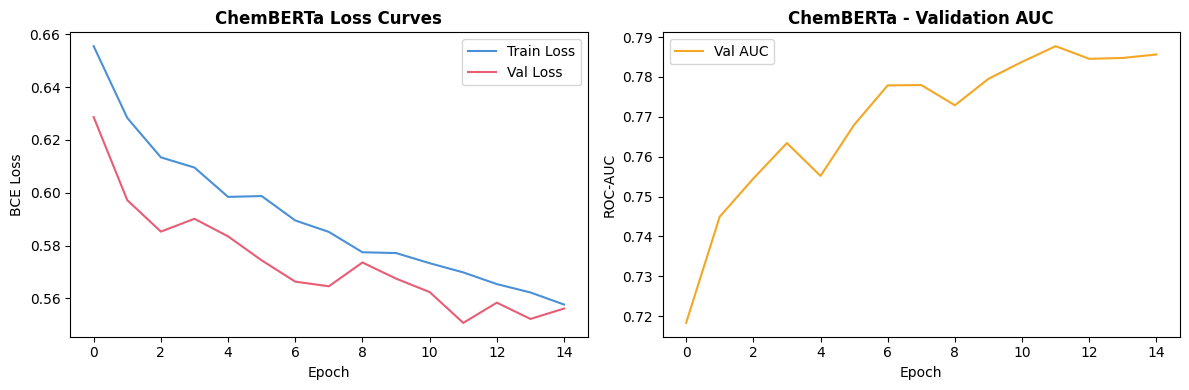

In [19]:
# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='Train Loss', color='#4A90D9')
ax1.plot(history['val_loss'], label='Val Loss', color='#E85D75')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCE Loss')
ax1.set_title('ChemBERTa Loss Curves', fontweight='bold')
ax1.legend()

ax2.plot(history['val_auc'], label='Val AUC', color='#F5A623')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('ROC-AUC')
ax2.set_title('ChemBERTa - Validation AUC', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}/chemberta_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# ---- Final evaluation on test set ----
test_loss, test_acc, test_f1, test_auc, y_prob_plm, y_true_plm = evaluate(
    model, test_loader_plm, criterion, device
)

y_pred_plm = (y_prob_plm >= 0.5).astype(int)
evaluate_and_store('ChemBERTa (frozen backbone)', y_test, y_pred_plm, y_prob_plm)
print('Classification Report:\n', classification_report(y_true_plm, y_pred_plm, target_names=['Non-Mutagenic', 'Mutagenic']))


ChemBERTa (frozen backbone)     Accuracy=0.7253 | F1 Score=0.7497 | ROC AUC= 0.8017
Classification Report:
                precision    recall  f1-score   support

Non-Mutagenic       0.70      0.69      0.70       658
    Mutagenic       0.75      0.75      0.75       798

     accuracy                           0.73      1456
    macro avg       0.72      0.72      0.72      1456
 weighted avg       0.73      0.73      0.73      1456



## 6. Results Comparison

In [21]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="ROC AUC", ascending=False).reset_index(
    drop=True
)

results_df.style.format(
    {"Accuracy": "{:.4f}", "F1 Score": "{:.4f}", "ROC AUC": "{:.4f}"}
).background_gradient(subset=["ROC AUC"], cmap="Greens")

,Model,Accuracy,ROC AUC,F1 Score
0,RF + Morgan FP,0.8249,0.9002,0.8389
1,XGB + Morgan FP,0.8255,0.8994,0.8416
2,RF + RDKit Descriptors,0.7864,0.8668,0.8060
3,ChemBERTa (frozen backbone),0.7253,0.8017,0.7497
4,Dummy (Stratified),0.5199,0.5166,0.5573
5,Dummy (Majority),0.5481,nan,0.7081


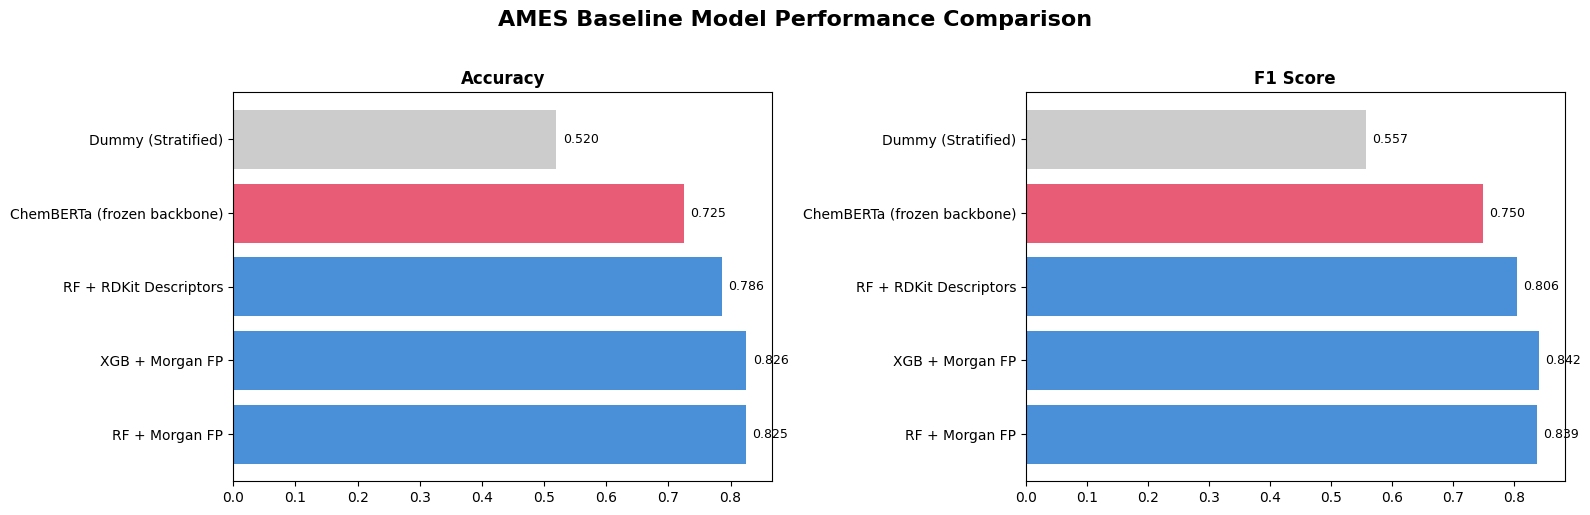

In [24]:
# Visual comparison of all models
plot_df = results_df[results_df["ROC AUC"].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, metric in zip(axes, ["Accuracy", "F1 Score", "ROC AUC"]):
    colors = [
        (
            "#4A90D9"
            if "RF" in m or "XGB" in m
            else "#E85D75" if "Chem" in m else "#CCCCCC"
        )
        for m in plot_df["Model"]
    ]
    ax.barh(plot_df["Model"], plot_df[metric], color=colors)
    ax.set_label(metric)
    ax.set_title(metric, fontweight="bold")
    # Add value labels
    for i, v in enumerate(plot_df[metric]):
        ax.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=9)

plt.suptitle("AMES Baseline Model Performance Comparison", fontweight="bold", fontsize=16, y =1.02)
plt.tight_layout()
plt.savefig(f"{PLOTS_PATH}/ames_baseline_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

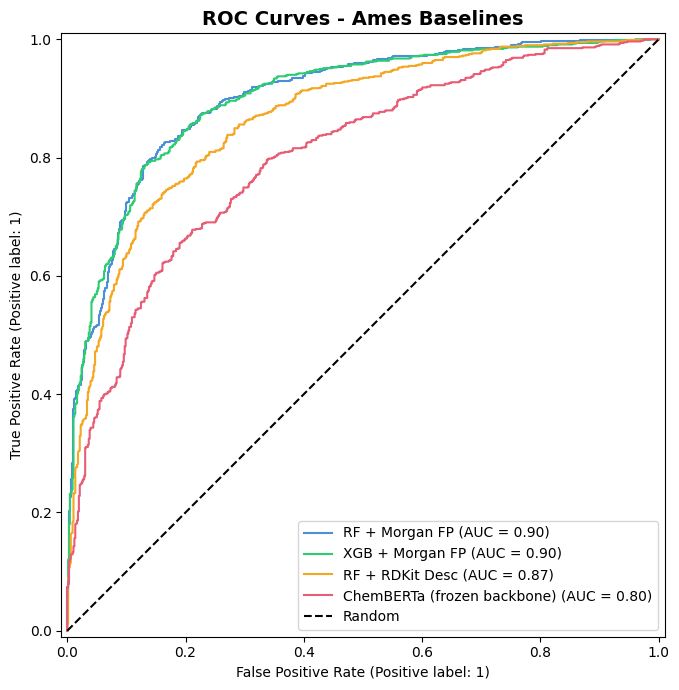

In [29]:
# ROC curves for all models
fig, ax = plt.subplots(figsize=(7, 7))

model_curves = {
    "RF + Morgan FP": (y_test, y_prob_rf, "#4A90D9"),
    "XGB + Morgan FP": (y_test, y_prob_xgb, "#2ECC71"),
    "RF + RDKit Desc": (y_test, y_prob_rf_desc, "#F5A623"),
    "ChemBERTa (frozen backbone)": (y_true_plm, y_prob_plm, "#E85D75")
}

for name , (y_true, y_prob, color) in model_curves.items():
    RocCurveDisplay.from_predictions(y_true, y_prob, name=name, ax=ax, color=color)

ax.plot([0, 1], [0, 1], "k--", label="Random")
ax.set_title("ROC Curves - Ames Baselines", fontsize=14, fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(f"{PLOTS_PATH}/ames_baseline_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Summary and Next Steps

**Key Questions answered by these baselines:**

| Comparison | Insight |
| --- | --- |
| Majority vs. ML Models | Task is learnable - ML provides meaningful lift |
| Morgan FP vs. RDKit descriptos | Which feature type works better for classical models? |
| Classical ML vs. ChemBERTa | Do *learned* representations beat *engineereed* ones? |

TODO : **Next** : Build GNN Models (GCN, GIN, GAT) in a new notebook and compare againt the baseilnes.
The critical question: **does explicit graph topology beat both fingerprints and the PLM?**